## Data Understanding

This notebook explores the F1 collected over time to understand Contructor, driver and race behaviours

In [1]:
import pandas as pd

In [4]:
df= pd.read_csv(r'C:\Users\Dilshani\Documents\F1_project\data\raw\podium_prediction_dataset.csv')

df.describe()


C:\Users\Dilshani\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,raceId,year,round,resultId,driverId,constructorId,qualifying_position,best_quali_ms,qualifying_gap_to_pole_ms,teammate_qualifying_gap_ms,...,constructor_points_last_5,constructor_podium_rate_last_5,avg_pit_ms_last_5,pit_consistency_last_5,total_pit_stops_last_5,driver_dnf_rate_last_10,constructor_dnf_rate_last_20,finish_position,points,podium_finish
count,84986.000000,84986.000000,84986.000000,84986.000000,84986.000000,84986.000000,7805.000000,7805.000000,7805.000000,7805.000000,...,83914.000000,83914.000000,24684.000000,24684.000000,24724.000000,80973.000000,84617.000000,84986.000000,84986.000000,84986.000000
mean,644.280576,1979.075095,6.772515,15712.837726,381.921587,68.400537,5.377578,87120.299295,949.505445,0.000000,...,30.203267,0.751339,34355.618907,34355.618907,17.575756,0.450400,0.439318,12.949321,1.532172,0.119243
std,279.500697,23.968325,5.018951,6901.040572,270.696911,61.645913,2.825487,12200.238955,1136.700542,464.312237,...,33.099902,0.920358,80811.004539,80811.004539,4.935326,0.271585,0.213897,7.779152,3.754040,0.324076
min,1.000000,1950.000000,1.000000,1.000000,1.000000,1.000000,1.000000,53377.000000,0.000000,-10033.500000,...,0.000000,0.000000,2.121320,2.121320,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,439.000000,1955.000000,2.000000,10805.000000,119.000000,9.000000,3.000000,76992.000000,328.000000,-75.000000,...,4.000000,0.000000,1421.836623,1421.836623,14.000000,0.200000,0.300000,7.000000,0.000000,0.000000
50%,760.000000,1975.000000,6.000000,18640.000000,385.000000,49.000000,5.000000,86869.000000,771.000000,0.000000,...,20.140000,0.400000,2620.498472,2620.498472,17.000000,0.428571,0.450000,12.000000,0.000000,0.000000
75%,809.000000,2000.000000,10.000000,20218.000000,608.000000,113.000000,8.000000,95134.000000,1312.000000,75.000000,...,46.000000,1.200000,7465.445296,7465.445296,21.000000,0.625000,0.600000,19.000000,1.000000,0.000000
max,1172.000000,2026.000000,24.000000,27331.000000,866.000000,217.000000,16.000000,129776.000000,31189.000000,10033.500000,...,222.000000,3.200000,708754.483946,708754.483946,34.000000,1.000000,1.000000,39.000000,50.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84986 entries, 0 to 84985
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   raceId                          84986 non-null  int64  
 1   year                            84986 non-null  int64  
 2   round                           84986 non-null  int64  
 3   race_name                       84986 non-null  object 
 4   race_date                       84986 non-null  object 
 5   resultId                        84986 non-null  int64  
 6   driverId                        84986 non-null  int64  
 7   constructorId                   84986 non-null  int64  
 8   driver_name                     84986 non-null  object 
 9   constructor_name                84986 non-null  object 
 10  grid                            84986 non-null  object 
 11  qualifying_position             7805 non-null   float64
 12  best_quali_ms                   

In [6]:
df.head(10)

,raceId,year,round,race_name,race_date,resultId,driverId,constructorId,driver_name,constructor_name,...,constructor_points_last_5,constructor_podium_rate_last_5,avg_pit_ms_last_5,pit_consistency_last_5,total_pit_stops_last_5,driver_dnf_rate_last_10,constructor_dnf_rate_last_20,finish_position,points,podium_finish
0,1,2009,1,Australian Grand Prix,2009-03-29 00:00:00.0000000,7556,15,7,Jarno Trulli,Toyota,...,16.0,0.2,1426.764744,1426.764744,19.0,0.1,0.10,3,6.0,1
1,1,2009,1,Australian Grand Prix,2009-03-29 00:00:00.0000000,7556,15,7,Jarno Trulli,Toyota,...,16.0,0.2,1426.764744,1426.764744,19.0,0.1,0.05,3,6.0,1
2,1,2009,1,Australian Grand Prix,2009-03-29 00:00:00.0000000,7557,10,7,Timo Glock,Toyota,...,16.0,0.2,1426.764744,1426.764744,19.0,0.1,0.10,4,5.0,0
3,1,2009,1,Australian Grand Prix,2009-03-29 00:00:00.0000000,7557,10,7,Timo Glock,Toyota,...,16.0,0.2,1426.764744,1426.764744,19.0,0.1,0.05,4,5.0,0
4,2,2009,2,Malaysian Grand Prix,2009-04-05 00:00:00.0000000,7577,15,7,Jarno Trulli,Toyota,...,21.0,0.4,1716.145897,1716.145897,13.0,0.2,0.15,4,2.5,0
5,2,2009,2,Malaysian Grand Prix,2009-04-05 00:00:00.0000000,7577,15,7,Jarno Trulli,Toyota,...,21.0,0.4,1716.145897,1716.145897,13.0,0.2,0.15,4,2.5,0
6,2,2009,2,Malaysian Grand Prix,2009-04-05 00:00:00.0000000,7576,10,7,Timo Glock,Toyota,...,21.0,0.4,1716.145897,1716.145897,13.0,0.1,0.15,3,3.0,1
7,2,2009,2,Malaysian Grand Prix,2009-04-05 00:00:00.0000000,7576,10,7,Timo Glock,Toyota,...,21.0,0.4,1716.145897,1716.145897,13.0,0.1,0.15,3,3.0,1
8,3,2009,3,Chinese Grand Prix,2009-04-19 00:00:00.0000000,7602,4,4,Fernando Alonso,Renault,...,6.0,0.2,1451.028322,1451.028322,14.0,0.3,0.30,9,0.0,0
9,3,2009,3,Chinese Grand Prix,2009-04-19 00:00:00.0000000,7602,4,4,Fernando Alonso,Renault,...,6.0,0.2,1451.028322,1451.028322,14.0,0.3,0.30,9,0.0,0


In [7]:
df['podium_finish'].value_counts()
df['podium_finish'].value_counts(normalize=True)

0    0.880757
1    0.119243
Name: podium_finish, dtype: float64

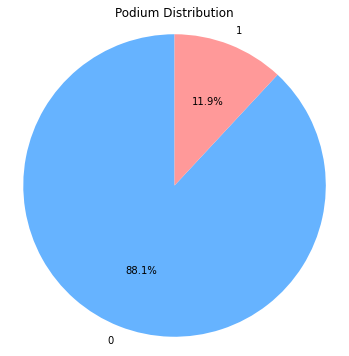

In [8]:
import matplotlib.pyplot as plt

# Get counts of the target variables
counts = df['podium_finish'].value_counts()

# Pie chart code
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#ff9999']  # optional colors
)

plt.title('Podium Distribution')
plt.axis('equal')  # keeps the pie circular
plt.show()

In [9]:
df.isnull().sum()

raceId                                0
year                                  0
round                                 0
race_name                             0
race_date                             0
resultId                              0
driverId                              0
constructorId                         0
driver_name                           0
constructor_name                      0
grid                                  0
qualifying_position               77181
best_quali_ms                     77181
qualifying_gap_to_pole_ms         77181
teammate_qualifying_gap_ms        77181
avg_finish_last_5                  4013
podiums_last_5                     4013
avg_qualifying_last_5             61123
dnf_rate_last_10                   4013
constructor_avg_finish_last_5      1072
constructor_points_last_5          1072
constructor_podium_rate_last_5     1072
avg_pit_ms_last_5                 60302
pit_consistency_last_5            60302
total_pit_stops_last_5            60262


In [10]:
df.duplicated().sum()

38818

In [11]:
df.columns

Index(['raceId', 'year', 'round', 'race_name', 'race_date', 'resultId',
       'driverId', 'constructorId', 'driver_name', 'constructor_name', 'grid',
       'qualifying_position', 'best_quali_ms', 'qualifying_gap_to_pole_ms',
       'teammate_qualifying_gap_ms', 'avg_finish_last_5', 'podiums_last_5',
       'avg_qualifying_last_5', 'dnf_rate_last_10',
       'constructor_avg_finish_last_5', 'constructor_points_last_5',
       'constructor_podium_rate_last_5', 'avg_pit_ms_last_5',
       'pit_consistency_last_5', 'total_pit_stops_last_5',
       'driver_dnf_rate_last_10', 'constructor_dnf_rate_last_20',
       'finish_position', 'points', 'podium_finish'],
      dtype='object')

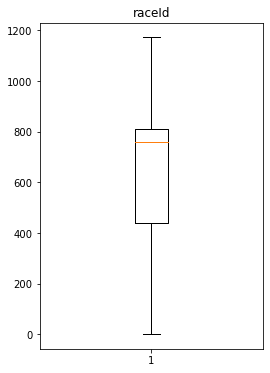

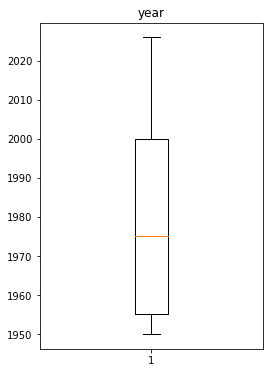

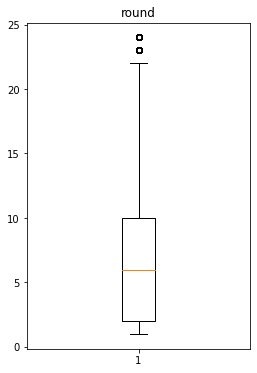

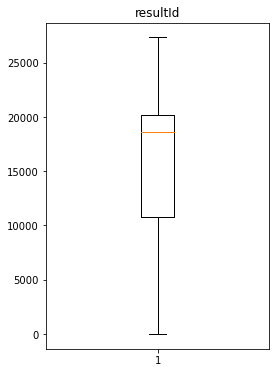

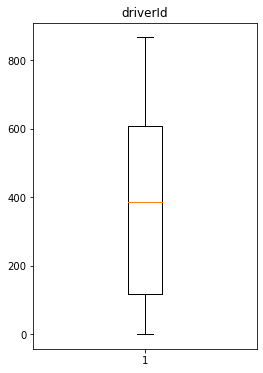

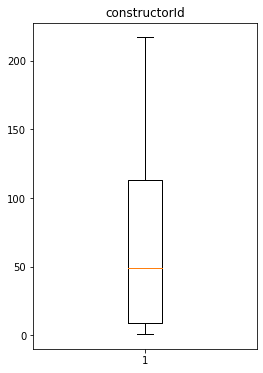

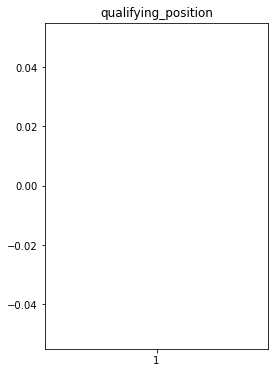

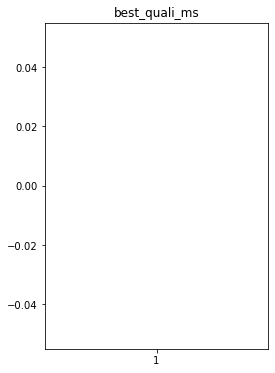

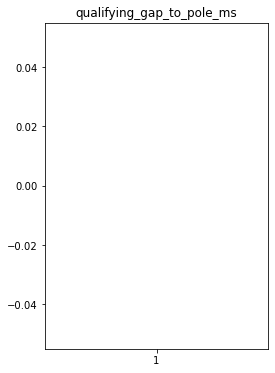

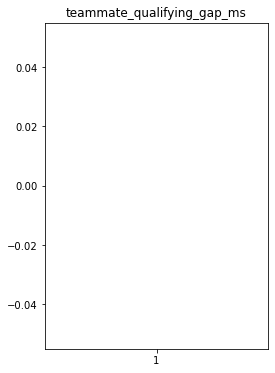

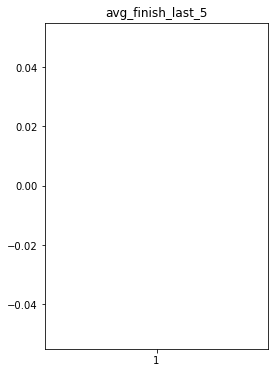

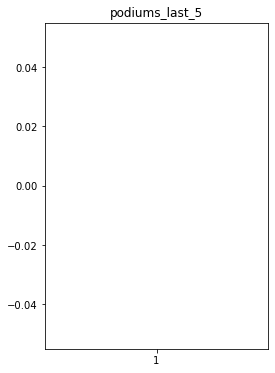

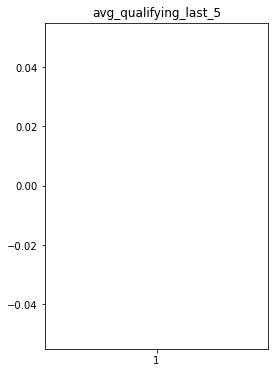

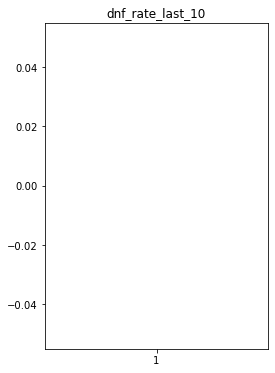

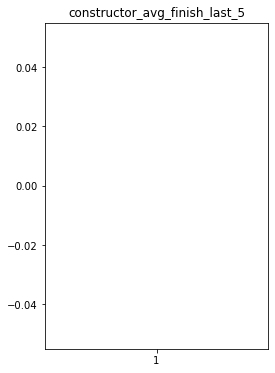

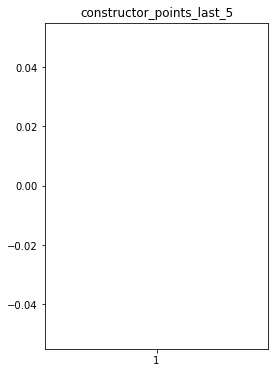

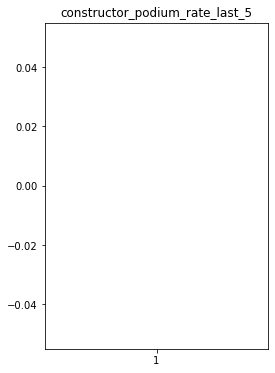

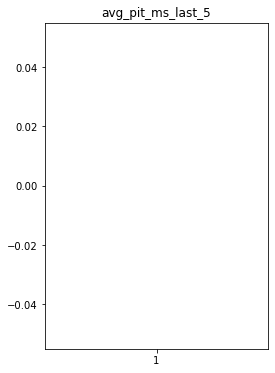

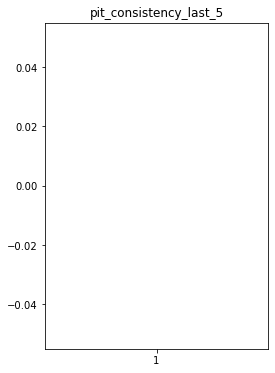

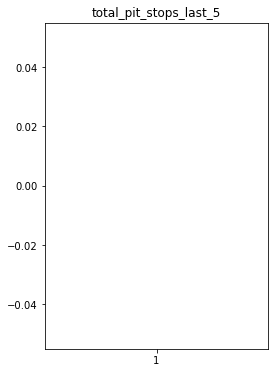

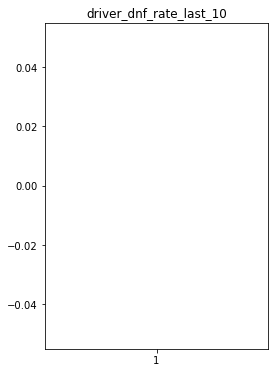

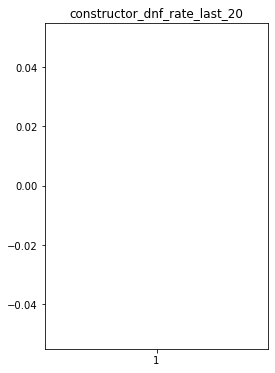

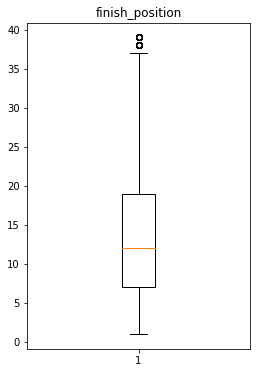

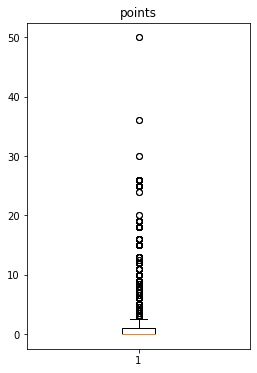

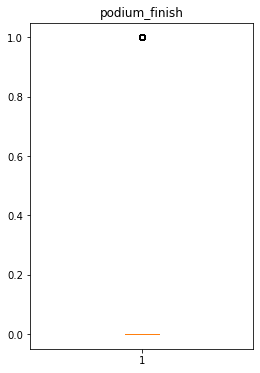

In [14]:
import matplotlib.pyplot as plt
cols = [
    'raceId', 'year', 'round', 'resultId',
       'driverId', 'constructorId', 
       'qualifying_position', 'best_quali_ms', 'qualifying_gap_to_pole_ms',
       'teammate_qualifying_gap_ms', 'avg_finish_last_5', 'podiums_last_5',
       'avg_qualifying_last_5', 'dnf_rate_last_10',
       'constructor_avg_finish_last_5', 'constructor_points_last_5',
       'constructor_podium_rate_last_5', 'avg_pit_ms_last_5',
       'pit_consistency_last_5', 'total_pit_stops_last_5',
       'driver_dnf_rate_last_10', 'constructor_dnf_rate_last_20',
       'finish_position', 'points', 'podium_finish'
]

for col in cols:
    plt.figure(figsize=(4, 6))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

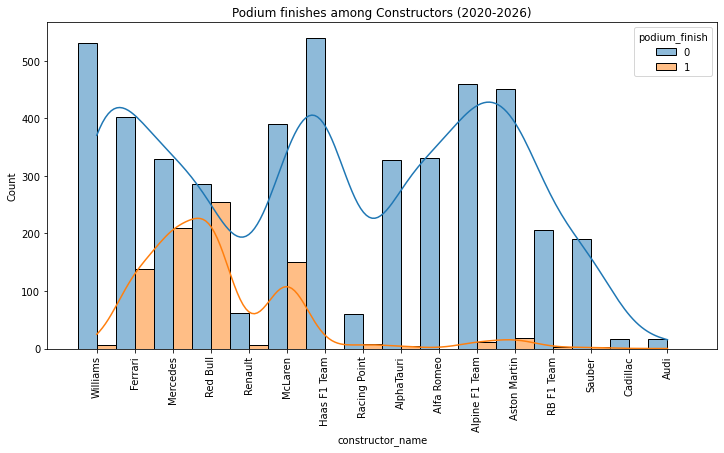

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter years
df_filtered = df[(df['year'] >= 2020) & (df['year'] <= 2026)]

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_filtered,
    x='constructor_name',
    hue='podium_finish',
    bins=30,
    kde=True,
    multiple='dodge'
)

plt.title('Podium finishes among Constructors (2020-2026)')
plt.xticks(rotation=90)

plt.show()

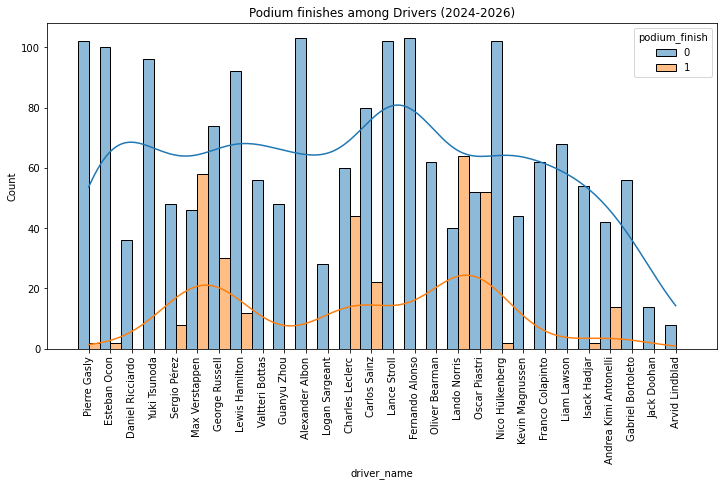

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter years
df_filtered = df[(df['year'] >= 2024) & (df['year'] <= 2026)]

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_filtered,
    x='driver_name',
    hue='podium_finish',
    bins=30,
    kde=True,
    multiple='dodge'
)

plt.title('Podium finishes among Drivers (2024-2026)')
plt.xticks(rotation=90)

plt.show()

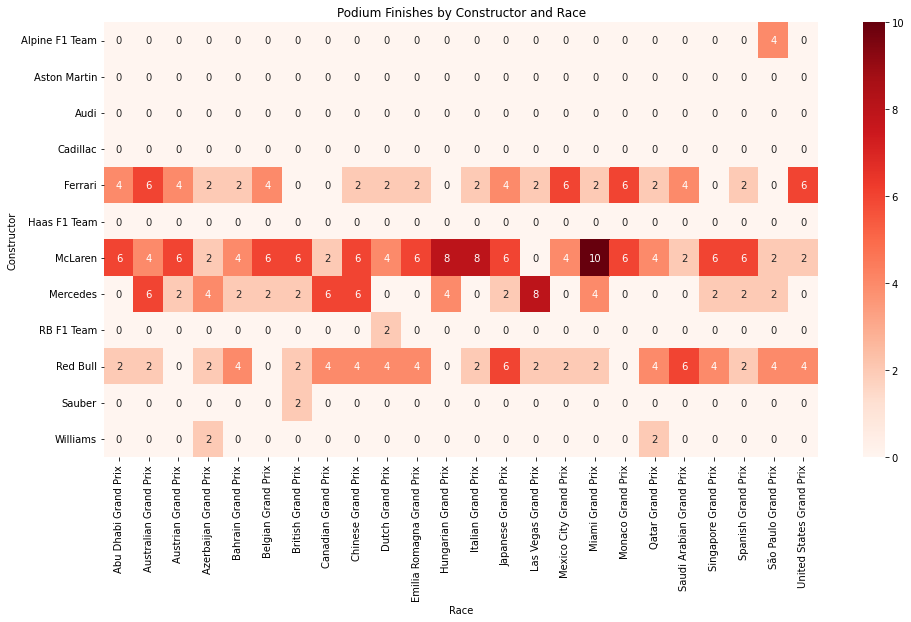

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered = df[(df['year'] >= 2024) & (df['year'] <= 2026)]

# Aggregate
df_heatmap = (
    df_filtered.groupby(['constructor_name', 'race_name'])['podium_finish']
    .sum()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(16,8))

sns.heatmap(
    df_heatmap,
    annot=True,
    cmap='Reds'
)

plt.title('Podium Finishes by Constructor and Race')
plt.xlabel('Race')
plt.ylabel('Constructor')

plt.show()

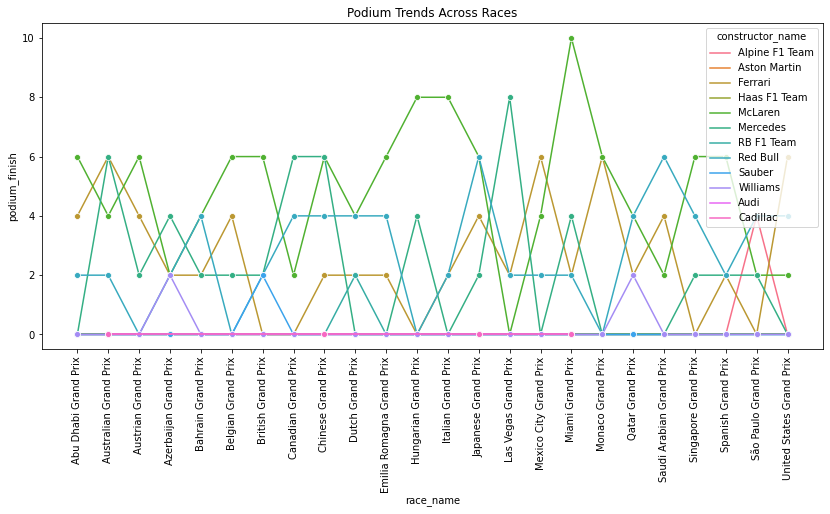

In [26]:
df_line = (
    df_filtered.groupby(['race_name', 'constructor_name'])['podium_finish']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_line,
    x='race_name',
    y='podium_finish',
    hue='constructor_name',
    marker='o'
)

plt.xticks(rotation=90)
plt.title('Podium Trends Across Races')

plt.show()

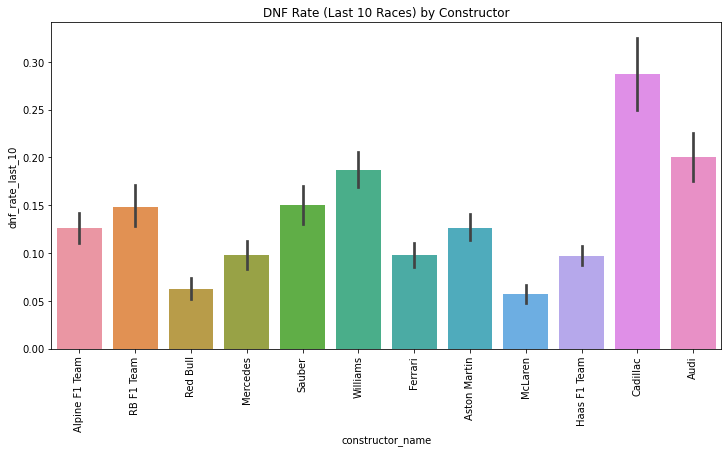

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered = df[(df['year'] >= 2024) & (df['year'] <= 2026)]


plt.figure(figsize=(12,6))

sns.barplot(
    data=df_filtered,
    x='constructor_name',
    y='dnf_rate_last_10'
)

plt.title('DNF Rate (Last 10 Races) by Constructor')
plt.xticks(rotation=90)

plt.show()

In [36]:
df_scatter = (
    df.groupby('constructor_name')[
        ['avg_qualifying_last_5', 'avg_finish_last_5']
    ]
    .mean()
    .reset_index()
)

current_teams = [
    'Red Bull',
    'Ferrari',
    'Mercedes',
    'McLaren',
    'Aston Martin',
    'Alpine F1 Team',
    'Williams',
    'RB',
    'Kick Sauber',
    'Haas F1 Team'
]

df_current = df_scatter[
    df_scatter['constructor_name'].isin(current_teams)
]

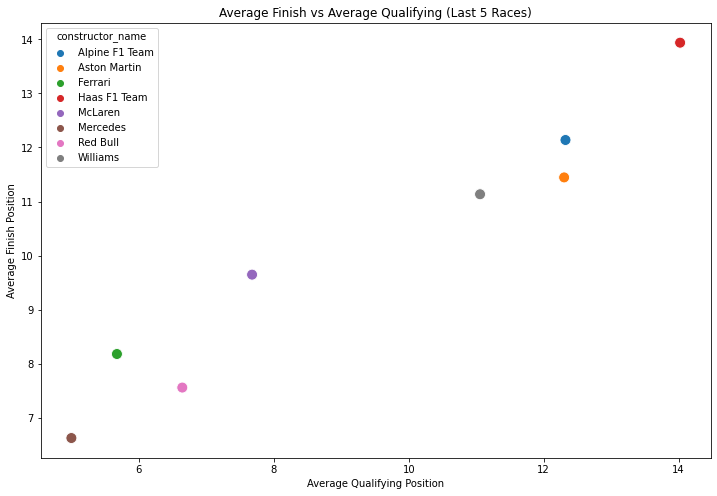

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df_current,
    x='avg_qualifying_last_5',
    y='avg_finish_last_5',
    hue='constructor_name',
    s=120
)

plt.title('Average Finish vs Average Qualifying (Last 5 Races)')
plt.xlabel('Average Qualifying Position')
plt.ylabel('Average Finish Position')

plt.show()

In [41]:
df_filtered = df[(df['year'] >= 2016) & (df['year'] <= 2026)]
numeric_df = df_filtered.select_dtypes(include=['int64', 'float64'])

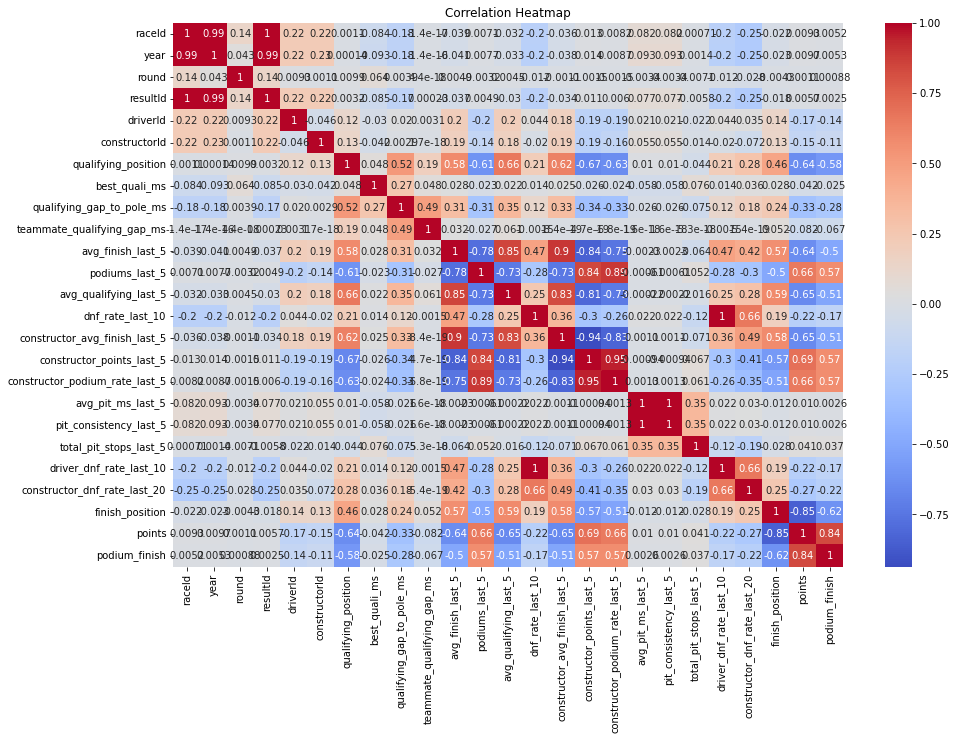

In [43]:
corr = numeric_df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()